# Maize Price Trends & Volatility Across Malawian Markets (2003–2026)

**Author:** Montfort Sayamika
**Data source:** [WFP Food Prices for Malawi](https://data.humdata.org/dataset/wfp-food-prices-for-malawi), via the Humanitarian Data Exchange (HDX), sourced from the World Food Programme Price Database.

## Why this matters

Maize is Malawi's staple food crop, and its price affects household food security more than almost any other single number in the economy. This notebook explores how maize retail prices have moved over more than two decades, what seasonal patterns exist, how regions compare, and where price volatility is highest.

## Questions this analysis answers
1. How has the maize price changed over time — and does looking at it in local currency (MWK) vs. US dollars tell a different story?
2. Is there a predictable seasonal pattern (e.g. cheaper after harvest, more expensive before)?
3. Do prices differ meaningfully by region (Northern, Central, Southern Malawi)?
4. Which markets have the most unstable (volatile) prices, and which are most stable?


## 1. Setup & Load

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("data/wfp_food_prices_mwi.csv")
print("Full dataset shape:", df.shape)
df.head()

Full dataset shape: (79285, 16)


,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,1990-10-15,NaN,NaN,National Average,1835,NaN,NaN,non-food,Fuel (diesel),284,L,actual,Retail,MWK,1.90,0.0130
1,1990-10-15,NaN,NaN,National Average,1835,NaN,NaN,non-food,"Fuel (kerosene, paraffin)",350,L,actual,Retail,MWK,1.22,0.0087
2,1991-08-15,NaN,NaN,National Average,1835,NaN,NaN,non-food,Fuel (diesel),284,L,actual,Retail,MWK,2.00,0.0140
3,1991-08-15,NaN,NaN,National Average,1835,NaN,NaN,non-food,"Fuel (kerosene, paraffin)",350,L,actual,Retail,MWK,1.22,0.0087
4,1992-06-15,NaN,NaN,National Average,1835,NaN,NaN,non-food,Fuel (diesel),284,L,actual,Retail,MWK,2.58,0.0180


The dataset covers 63 different commodities and food items across markets in Malawi. We focus on **Maize**, since it's the staple crop and has the largest, most complete price history in the data.

In [2]:
print("Commodities available:", df['commodity'].nunique())
df['commodity'].value_counts().head(10)

Commodities available: 63


commodity
Maize                   13986
Beans                    6711
Rice                     4653
Groundnuts (shelled)     3520
Cowpeas                  3256
Maize (new harvest)      2730
Pigeon peas              2451
Cassava                  2426
Sugar                    1644
Oil (vegetable)          1642
Name: count, dtype: int64

## 2. Filter & Clean

In [3]:
maize = df[df["commodity"] == "Maize"].copy()
maize["date"] = pd.to_datetime(maize["date"])
maize["year"] = maize["date"].dt.year
maize["month"] = maize["date"].dt.month

print("Maize records:", len(maize))
print("Date range:", maize['date'].min().date(), "to", maize['date'].max().date())
print("Missing values:\n", maize.isnull().sum().sum(), "total nulls")
print("Currency:", maize['currency'].unique(), "| Unit:", maize['unit'].unique())

Maize records: 13986
Date range: 2003-01-15 to 2026-04-15
Missing values:
 0 total nulls
Currency: <StringArray>
['MWK']
Length: 1, dtype: str | Unit: <StringArray>
['KG']
Length: 1, dtype: str


In [4]:
# Sanity check: drop any non-positive prices (defensive cleaning, even if none exist)
before = len(maize)
maize = maize[maize["price"] > 0]
print(f"Dropped {before - len(maize)} invalid rows")

# Check for reporting gaps - important to surface rather than hide
years_present = sorted(maize['year'].unique())
all_years = set(range(min(years_present), max(years_present)+1))
missing_years = sorted(all_years - set(years_present))
print("Years with NO reported data:", missing_years)

Dropped 0 invalid rows
Years with NO reported data: [2023, 2024]


**Data quality note:** there is a real reporting gap for **2023–2024** — no records exist for these years in the source data. This isn't a cleaning artifact; it reflects an actual gap in WFP's reporting for Malawi during that period. Any conclusions about 2025–2026 should be read with that gap in mind, since we can't see what happened in between.

## 3. Price Trend Over Time: MWK vs. USD

Malawi's currency (MWK) has devalued significantly over the past two decades. Looking only at the MWK price would make maize look like it's had runaway hyperinflation — which is *partly* true, but mixes two different effects together: currency devaluation and the actual change in what maize costs in real terms. Comparing MWK and USD side by side separates these two stories.

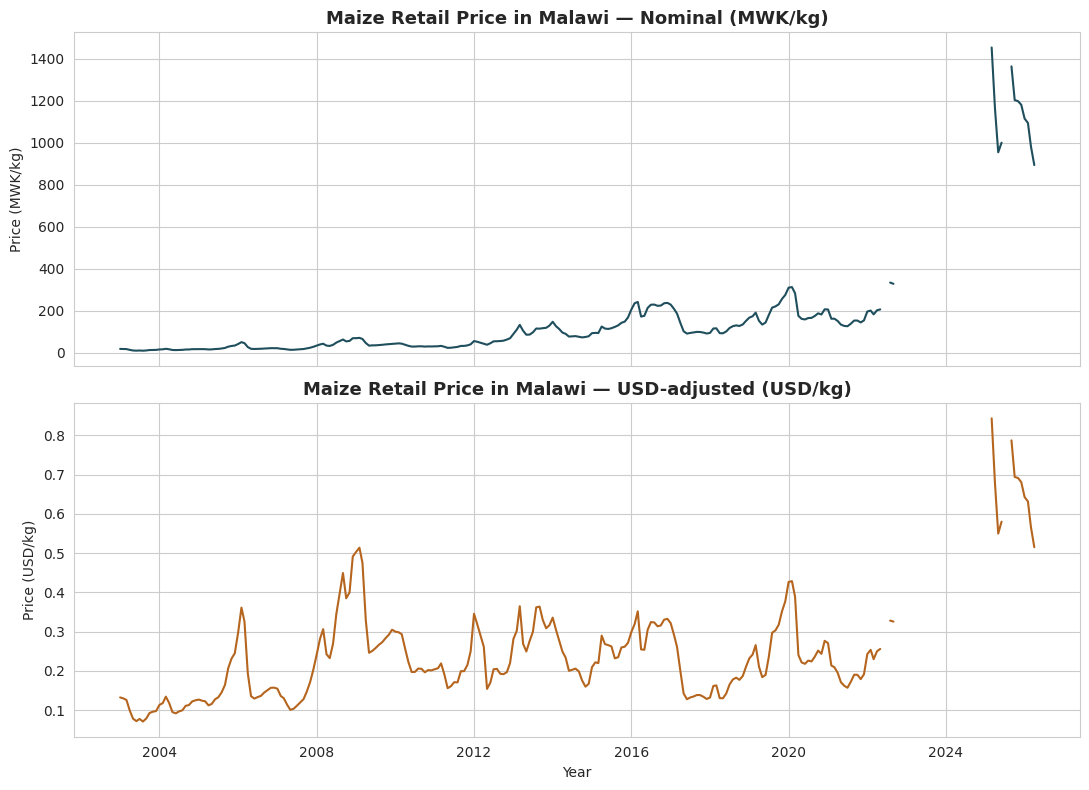

In [5]:
monthly = maize.groupby(pd.Grouper(key="date", freq="MS")).agg(
    mwk_price=("price", "mean"),
    usd_price=("usdprice", "mean")
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

axes[0].plot(monthly["date"], monthly["mwk_price"], color="#1F4E5C", linewidth=1.5)
axes[0].set_title("Maize Retail Price in Malawi — Nominal (MWK/kg)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Price (MWK/kg)")

axes[1].plot(monthly["date"], monthly["usd_price"], color="#B5651D", linewidth=1.5)
axes[1].set_title("Maize Retail Price in Malawi — USD-adjusted (USD/kg)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Price (USD/kg)")
axes[1].set_xlabel("Year")

plt.tight_layout()
plt.savefig("figures/01_price_trend_mwk_vs_usd.png", dpi=150)
plt.show()

In [6]:
first_valid = monthly.dropna().iloc[0]
last_valid = monthly.dropna().iloc[-1]
mwk_growth = (last_valid['mwk_price'] / first_valid['mwk_price'] - 1) * 100
usd_growth = (last_valid['usd_price'] / first_valid['usd_price'] - 1) * 100

print(f"From {first_valid['date'].date()} to {last_valid['date'].date()}:")
print(f"  MWK price change: {mwk_growth:,.0f}%")
print(f"  USD price change: {usd_growth:,.0f}%")

From 2003-01-01 to 2026-04-01:
  MWK price change: 4,703%
  USD price change: 288%


**Finding:** the nominal MWK price rose roughly **47x** over the period, but in USD terms the rise was much smaller (~3.9x). This confirms that most of the dramatic-looking MWK price increase is a currency devaluation effect, not purely a "real" maize shortage story. The USD chart also reveals a clear repeating **sawtooth pattern** — prices spike, then fall, year after year. That's worth investigating directly: it looks seasonal.

## 4. Seasonal Pattern

Malawi's main maize harvest happens around April–June. If maize prices follow the harvest calendar, we'd expect prices to be **lowest right after harvest** (more supply) and **highest just before the next harvest** (stocks running low — sometimes called the "hunger season").

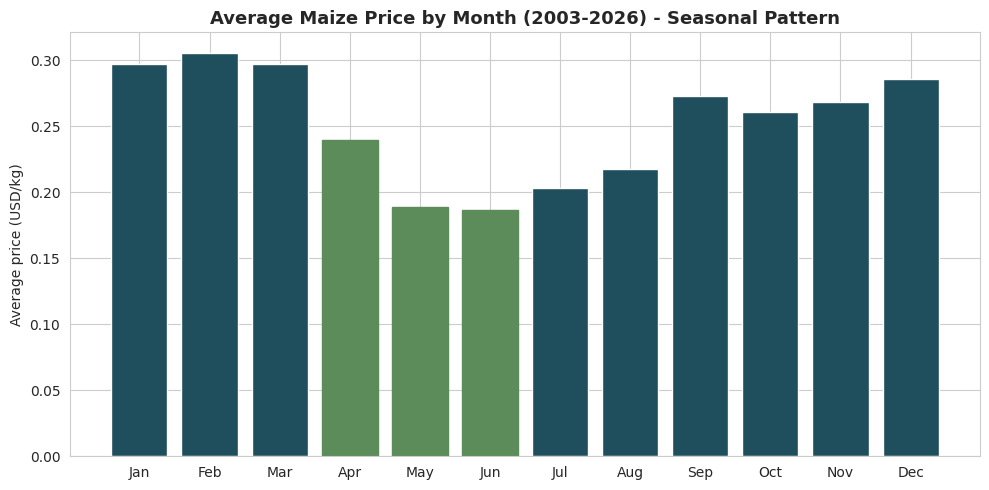

,month,usdprice
0,1,0.296784
1,2,0.305847
2,3,0.297095
3,4,0.239673
4,5,0.188744
5,6,0.186663
6,7,0.203340
7,8,0.217545
8,9,0.273164
9,10,0.261122


In [7]:
seasonal = maize.groupby("month")["usdprice"].mean().reset_index()
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(seasonal["month"], seasonal["usdprice"], color="#1F4E5C")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_ylabel("Average price (USD/kg)")
ax.set_title("Average Maize Price by Month (2003-2026) - Seasonal Pattern", fontsize=13, fontweight="bold")

for i, bar in enumerate(bars):
    if seasonal["month"].iloc[i] in [4, 5, 6]:
        bar.set_color("#5B8C5A")  # highlight harvest months in green

plt.tight_layout()
plt.savefig("figures/02_seasonal_pattern.png", dpi=150)
plt.show()

seasonal

**Finding:** the pattern matches expectations almost exactly. **May and June (right after harvest)** are the cheapest months (~$0.19/kg), while **February (just before harvest)** is the most expensive (~$0.31/kg) — about **60% higher**. This is a clear, consistent seasonal effect, not noise.

## 5. Regional Comparison

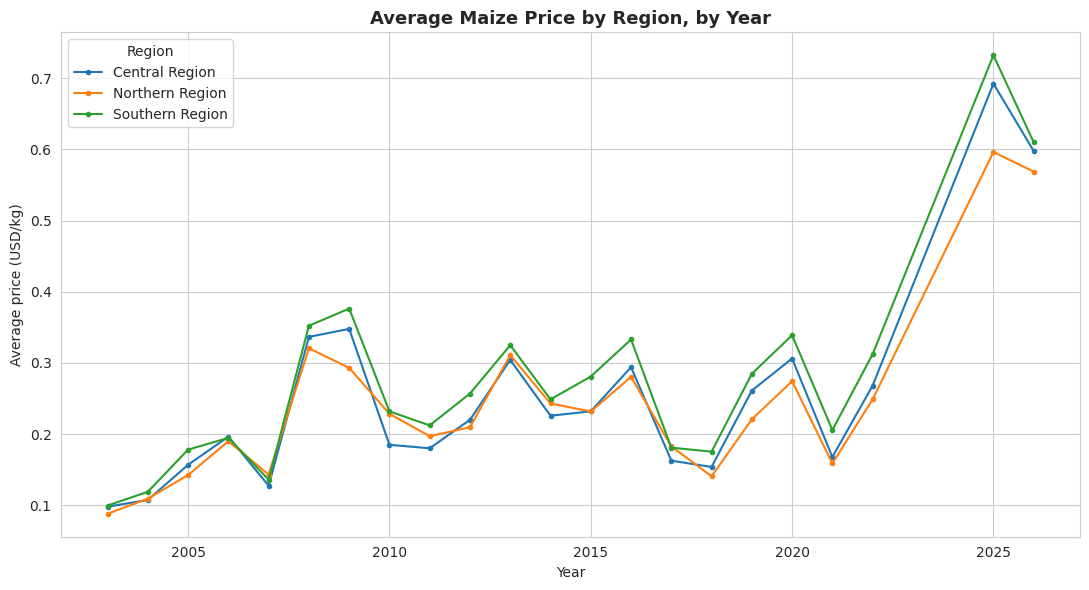

In [8]:
regional = maize.groupby(["year", "admin1"])["usdprice"].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 6))
for region in regional["admin1"].unique():
    sub = regional[regional["admin1"] == region]
    ax.plot(sub["year"], sub["usdprice"], marker="o", markersize=3, label=region)

ax.set_title("Average Maize Price by Region, by Year", fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Average price (USD/kg)")
ax.legend(title="Region")
plt.tight_layout()
plt.savefig("figures/03_regional_comparison.png", dpi=150)
plt.show()

**Finding:** the **Southern Region is consistently the most expensive** for maize across nearly every year in the dataset, and the **Northern Region is consistently the cheapest**. The gap is fairly stable over time rather than widening or narrowing — it looks like a persistent structural difference (e.g. transport distance, local production levels) rather than a one-off event.

## 6. Volatility: Which Markets Are Most Unstable?

A high average price isn't the same as an unpredictable price. Here we measure volatility using the **coefficient of variation** (standard deviation ÷ mean), which lets us fairly compare volatility across markets with very different price levels.

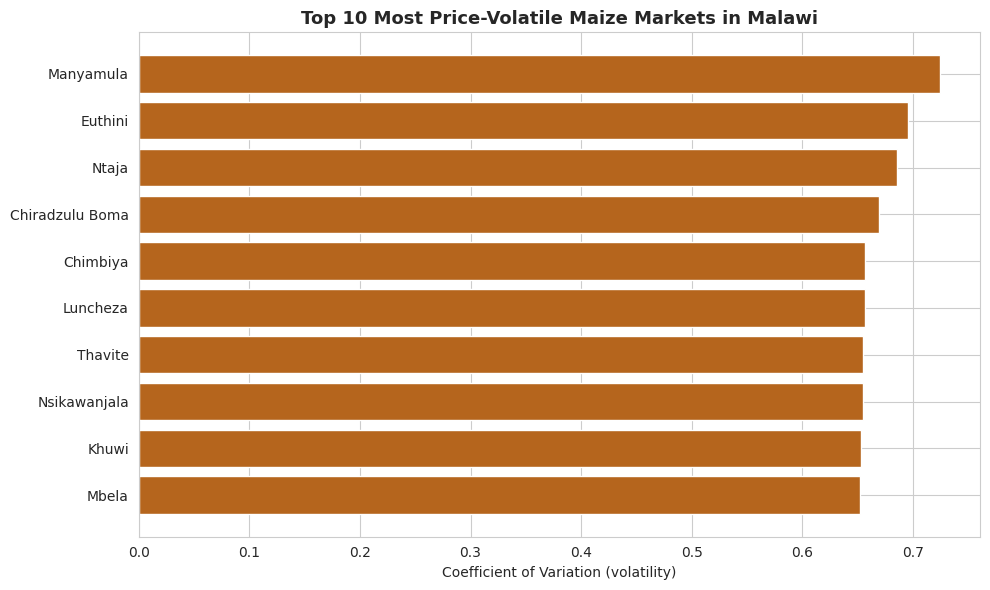

Most stable markets:


,market,mean,std,cv
100,Santhe,0.214176,0.085564,0.399504
72,Mzuzu,0.222762,0.084230,0.378118
36,Lilongwe,0.248439,0.093602,0.376759
57,Misuku,0.169121,0.059538,0.352044
10,Chilumba,0.244400,0.079640,0.325861


In [9]:
market_counts = maize["market"].value_counts()
valid_markets = market_counts[market_counts >= 50].index  # only markets with enough data
sub = maize[maize["market"].isin(valid_markets)]

vol_by_market = sub.groupby("market")["usdprice"].agg(["mean", "std"]).reset_index()
vol_by_market["cv"] = vol_by_market["std"] / vol_by_market["mean"]
vol_by_market = vol_by_market.sort_values("cv", ascending=False)

top10 = vol_by_market.head(10)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top10["market"], top10["cv"], color="#B5651D")
ax.set_xlabel("Coefficient of Variation (volatility)")
ax.set_title("Top 10 Most Price-Volatile Maize Markets in Malawi", fontsize=13, fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("figures/04_market_volatility.png", dpi=150)
plt.show()

print("Most stable markets:")
vol_by_market.tail(5)

**Finding:** **Manyamula, Euthini, and Ntaja** show the highest price volatility (CV > 0.68) — prices there swing widely relative to their average. Markets like **Chilumba, Misuku, and Lilongwe** are comparatively stable. This kind of result would matter to an NGO or government agency deciding where to focus price-stabilization or market-information interventions.

## 7. Summary of Findings

1. **Currency matters.** Nominal MWK maize prices rose ~47x since 2003, but the USD-adjusted price rose only ~3.9x — most of the apparent "explosion" in price is currency devaluation, not a real supply crisis.
2. **Seasonality is real and large.** Prices are ~60% higher in February (pre-harvest) than in May/June (post-harvest) on average.
3. **Region matters.** Southern Region consistently pays more for maize than Northern Region, every year, suggesting a structural rather than temporary gap.
4. **Volatility varies a lot by market.** Some markets (e.g. Manyamula) are far less predictable than others (e.g. Chilumba), which matters for anyone planning around food prices locally.
5. **Data quality caveat.** There's a real gap in reporting for 2023–2024, which limits how confidently we can describe the transition into the 2025-26 price spike.

## Tools used
`pandas`, `matplotlib`, `seaborn` for cleaning, aggregation, and visualization.
